# Independent methylpy rDNA methylation workflow

This notebook is built to run from start to finish using the current `~/rDNA_repro` folder structure.

It is resume-safe: each major step checks for expected output files first, skips completed work, and prints checkpoint/status tables. The methylpy section no longer depends on BAMs or variables created in a different workbook; the notebook creates/checks the deduplicated rDNA BAMs before calling methylpy.

Expected project layout:

```text
~/rDNA_repro/
  samples_manifest.csv
  raw/
  ref/
    rDNA_45S.fa
    45S_annotation.csv
  work/
    trimmed/
    bams_rDNA/
    dedup_rDNA/
    methylpy_rDNA/
  out/
    figures/
    summary/
  logs/
```


In [1]:
from pathlib import Path
import subprocess, os
import pandas as pd

# --- Canonical project paths (reuse these in every cell) ---
PROJECT  = Path.home() / "rDNA_repro"
RAW      = PROJECT / "raw"
REF      = PROJECT / "ref"
WORK     = PROJECT / "work"
OUT      = PROJECT / "out"
LOGS     = PROJECT / "logs"
MANIFEST = PROJECT / "samples_manifest.csv"

for d in [RAW, REF, WORK, OUT, LOGS]:
    d.mkdir(parents=True, exist_ok=True)

threads = 46

manifest = pd.read_csv(MANIFEST)
manifest.columns = [c.strip().lower() for c in manifest.columns]
manifest["sample_id"] = manifest["sample_id"].astype(str).str.strip()
manifest["srr"] = manifest["srr"].astype(str).str.strip()

print(manifest)

def run(cmd):
    print("Running:", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)

# -------------------------
# 1) Download each SRR (run-level)
# -------------------------
for _, row in manifest.iterrows():
    srr = row["srr"]
    out_fastq = RAW / f"{srr}.fastq.gz"
    if out_fastq.exists():
        print(f"✅ {out_fastq} already exists, skipping.")
        continue

    print(f"\n=== Fetching {srr} (sample: {row['sample_id']}) ===")
    run(["fasterq-dump", srr, "-e", str(threads), "-p", "-O", str(RAW)])

    fq = RAW / f"{srr}.fastq"
    if fq.exists():
        print(f"Compressing {fq} ...")
        run(["pigz", "-p", str(threads), str(fq)])
    else:
        raise FileNotFoundError(f"Expected {fq} not found after fasterq-dump")

    size_gb = os.path.getsize(out_fastq) / 1e9
    print(f"Saved {out_fastq}, size = {size_gb:.2f} GB")

# -------------------------
# 2) Define per-sample FASTQ (merge only if >1 SRR)
# -------------------------
sample_fastq = {}

print("\n=== Resolving per-sample FASTQs (merge only if needed) ===")
for sid, df in manifest.groupby("sample_id", sort=False):
    srrs = df["srr"].tolist()

    if len(srrs) == 1:
        # No merge needed: sample FASTQ is the run FASTQ
        fq = RAW / f"{srrs[0]}.fastq.gz"
        if not fq.exists():
            raise FileNotFoundError(f"Missing {fq} for sample {sid}")
        sample_fastq[sid] = fq
        print(f"{sid}: single run -> {fq.name}")

    else:
        # Merge multiple SRRs for the same biological sample
        merged = RAW / f"{sid}.fastq.gz"

        inputs = [RAW / f"{s}.fastq.gz" for s in srrs]
        missing = [p for p in inputs if not p.exists()]
        if missing:
            raise FileNotFoundError(f"Missing FASTQs for {sid}: {missing}")

        if merged.exists():
            print(f"{sid}: multi-run -> {merged.name} (already exists, skipping merge)")
        else:
            print(f"{sid}: multi-run -> merging {srrs} -> {merged.name}")
            # Concatenating gz files is valid and keeps the reads intact.
            with open(merged, "wb") as w:
                for p in inputs:
                    with open(p, "rb") as r:
                        w.write(r.read())

            size_gb = os.path.getsize(merged) / 1e9
            print(f"✅ Wrote {merged}, size = {size_gb:.2f} GB")

        sample_fastq[sid] = merged

print("\nPer-sample FASTQ mapping:")
for k, v in sample_fastq.items():
    print(f"  {k}: {v}")

import os
import subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

QC_DIR = OUT / "qc" / "fastqc"
QC_DIR.mkdir(parents=True, exist_ok=True)

# --- Build the EXACT per-sample FASTQs to QC ---
# Assumes you already ran the previous cell that created `sample_fastq` dict.
# If not, this will error loudly (by design).
if "sample_fastq" not in globals():
    raise RuntimeError("`sample_fastq` not found. Run the download/merge cell first to create it.")

# Only QC the per-sample FASTQ actually used downstream:
# - single-SRR samples -> SRR.fastq.gz
# - multi-SRR samples  -> sample_id.fastq.gz (merged)
fastqs = sorted(set(sample_fastq.values()))
missing = [f for f in fastqs if not f.exists()]
if missing:
    raise FileNotFoundError(f"Some per-sample FASTQs are missing: {missing}")

print(f"Will FastQC {len(fastqs)} per-sample FASTQs:")
for sid, fq in sorted(sample_fastq.items()):
    print(f"  {sid}: {fq.name}")

# Per-file threads and overall parallelism
per_file_threads = 5
max_workers = max(1, min(len(fastqs), threads // per_file_threads))

def fastqc_outputs(fq: Path):
    """Return expected FastQC output paths for a FASTQ."""
    base = fq.name
    for suf in (".fastq.gz", ".fq.gz", ".fastq", ".fq"):
        if base.endswith(suf):
            base = base[: -len(suf)]
            break
    return QC_DIR / f"{base}_fastqc.zip", QC_DIR / f"{base}_fastqc.html"

def needs_qc(fq: Path) -> bool:
    zip_out, html_out = fastqc_outputs(fq)
    return not (zip_out.exists() and html_out.exists())

def run_fastqc(fq: Path):
    if not needs_qc(fq):
        print(f"✅ FastQC already present for {fq.name}, skipping.")
        return
    cmd = ["fastqc", "--threads", str(per_file_threads), "-o", str(QC_DIR), str(fq)]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

# Run with bounded concurrency
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(run_fastqc, fq) for fq in fastqs]
    for fut in as_completed(futures):
        fut.result()  # raise if any job failed

print("\n✅ Parallel FastQC finished (per-sample only). Reports in:", QC_DIR)

from pathlib import Path
import pandas as pd
from bs4 import BeautifulSoup

QC_DIR = OUT / "qc" / "fastqc"

def parse_fastqc_html(html_path: Path):
    """Return a list of dicts: {sample, module, status} for one FastQC HTML."""
    with open(html_path, "r", encoding="utf-8", errors="ignore") as f:
        soup = BeautifulSoup(f, "lxml")

    # Sample name: use the HTML filename base (this matches what you QC'd: per-sample FASTQs)
    # e.g. drm1_2.fastq.gz -> drm1_2_fastqc.html -> sample=drm1_2
    sample = html_path.stem.replace("_fastqc", "")

    records = []
    for li in soup.select("div.summary ul li"):
        cls = li.get("class") or []
        if any(c.lower() == "pass" for c in cls):
            status = "PASS"
        elif any(c.lower() == "warn" for c in cls):
            status = "WARN"
        elif any(c.lower() == "fail" for c in cls):
            status = "FAIL"
        else:
            # Fallback to bracket tags in text
            t = li.decode().upper()
            status = "PASS" if "[PASS]" in t else "WARN" if "[WARN]" in t else "FAIL"

        text = li.get_text(" ", strip=True)
        for tag in ("[PASS]", "[WARN]", "[FAIL]"):
            text = text.replace(tag, "")
        module = text.strip()

        records.append({"sample": sample, "module": module, "status": status})

    # Extra safety: if FastQC HTML structure changes / parsing fails
    if not records:
        raise RuntimeError(f"Could not parse FastQC summary from: {html_path}")

    return records

# ---- Parse all FastQC reports in the canonical folder ----
html_reports = sorted(QC_DIR.glob("*_fastqc.html"))
assert html_reports, f"No FastQC HTML files found in {QC_DIR}"

all_records = []
for html in html_reports:
    all_records.extend(parse_fastqc_html(html))

df = pd.DataFrame(all_records)

# Optional: map SRR-only names to sample_id if you have `sample_fastq` + manifest loaded
# (keeps everything consistent with your manifest naming)
if "sample_fastq" in globals() and "manifest" in globals():
    # Build reverse map: fastq basename (without .fastq.gz) -> sample_id
    # For single-SRR samples, the FastQC name will be SRRxxxxxx
    # For multi-run, it will be sample_id
    srr_to_sample = dict(zip(manifest["srr"].astype(str).str.strip(), manifest["sample_id"].astype(str).str.strip()))
    df["sample"] = df["sample"].map(lambda x: srr_to_sample.get(x, x))

pivot = df.pivot(index="sample", columns="module", values="status")

# Sort by sample; keep module column order stable (alphabetical)
pivot = pivot.reindex(sorted(pivot.index))
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

# Save tidy + wide versions
tidy_csv  = QC_DIR / "fastqc_summary_tidy.csv"
wide_csv  = QC_DIR / "fastqc_summary_wide.csv"
df.to_csv(tidy_csv, index=False)
pivot.to_csv(wide_csv)

print(pivot.to_string())
print(f"\nSaved: {tidy_csv}")
print(f"Saved: {wide_csv}")

import subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRIM_DIR = WORK / "trimmed"
TRIM_DIR.mkdir(parents=True, exist_ok=True)

if "sample_fastq" not in globals():
    raise RuntimeError("`sample_fastq` not found. Run the download/merge cell first to create it.")

def input_base(fq: Path) -> str:
    name = fq.name
    for suf in (".fastq.gz", ".fq.gz", ".fastq", ".fq"):
        if name.endswith(suf):
            return name[: -len(suf)]
    return fq.stem

def outdir_for_fq(fq: Path) -> Path:
    # Match your current structure: TRIM_DIR/<input_basename>/
    return TRIM_DIR / input_base(fq)

def has_trimmed(outdir: Path) -> bool:
    return bool(list(outdir.glob("*_trimmed.fq.gz")) + list(outdir.glob("*_trimmed.fastq.gz")))

def run_trim(sample_id: str, fq: Path, per_job_cores: int):
    outdir = outdir_for_fq(fq)
    outdir.mkdir(parents=True, exist_ok=True)

    if has_trimmed(outdir):
        print(f"✅ {sample_id}: trimmed output already exists in {outdir.name}, skipping.")
        return f"skip:{sample_id}"

    cmd = [
        "trim_galore",
        "--cores", str(per_job_cores),
        "--fastqc",
        "--output_dir", str(outdir),
        str(fq),
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    if not has_trimmed(outdir):
        raise RuntimeError(f"Trim Galore finished but no *_trimmed.*.gz found in {outdir}")
    return f"done:{sample_id}"

# ---- plan jobs by checking existing outputs (correctly) ----
jobs = []
skipped_now = 0

for sample_id, fq in sample_fastq.items():
    fq = Path(fq)
    if not fq.exists():
        raise FileNotFoundError(f"Missing input FASTQ for {sample_id}: {fq}")

    outdir = outdir_for_fq(fq)
    if has_trimmed(outdir):
        skipped_now += 1
    else:
        jobs.append((sample_id, fq))

n_jobs = len(jobs)
print(f"Per-sample FASTQs total: {len(sample_fastq)}")
print(f"Already trimmed (will skip): {skipped_now}")
print(f"Jobs to run now: {n_jobs}")
print("Jobs:", [sid for sid, _ in jobs])

if n_jobs == 0:
    print("✅ Nothing to do (all samples already trimmed in the existing SRR-named folders).")
else:
    # ---- allocate cores across only remaining jobs ----
    total_cores = max(1, threads - 2)
    per_job_cores = max(1, total_cores // n_jobs)
    max_workers = min(n_jobs, total_cores // per_job_cores)

    print(f"Core budget: {threads} total -> using {total_cores} (leaving 2 free)")
    print(f"Planned: {n_jobs} jobs | per-job cores: {per_job_cores} | max workers: {max_workers}")

    # ---- run ----
    done, skipped = 0, 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(run_trim, sid, fq, per_job_cores): sid for sid, fq in jobs}
        for fut in as_completed(futures):
            tag = fut.result()
            if tag.startswith("skip:"):
                skipped += 1
            else:
                done += 1

    print(f"\n✅ Trim Galore complete. New: {done}, Skipped (pre-existing): {skipped_now + skipped}. Outputs in: {TRIM_DIR}")

from pathlib import Path
import pandas as pd

TRIM_DIR = WORK / "trimmed"

# Collect all FastQC reports produced by Trim Galore (inside each trimming output folder)
html_reports = sorted(TRIM_DIR.glob("*/*_fastqc.html"))
assert html_reports, f"No FastQC HTML files found under {TRIM_DIR} (expected '*/*_fastqc.html')."

all_rows = []
for html in html_reports:
    sample = html.parent.name  # matches your folder naming: SRR... or drm1_2
    all_rows.extend(parse_fastqc_html(html))  # parse_fastqc_html already extracts sample from filename

df = pd.DataFrame(all_rows)

# Ensure sample column matches folder naming (not whatever FastQC header says)
df["sample"] = df["sample"].astype(str).where(df["sample"].astype(str).str.len() > 0, sample)

pivot = df.pivot(index="sample", columns="module", values="status")
pivot = pivot.reindex(sorted(pivot.index))
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

# Save alongside trimmed outputs
tidy_csv = TRIM_DIR / "trim_galore_fastqc_summary_tidy.csv"
wide_csv = TRIM_DIR / "trim_galore_fastqc_summary_wide.csv"
df.to_csv(tidy_csv, index=False)
pivot.to_csv(wide_csv)

print(pivot.to_string())
print(f"\nSaved: {tidy_csv}")
print(f"Saved: {wide_csv}")


  sample_id        srr    label
0   WT_rep2  SRR534177  WT_rep2
1      cmt2  SRR869314     cmt2
2      cmt3  SRR534209     cmt3
3      ddm1  SRR534215     ddm1
4      met1  SRR534239     met1
5    drm1_2  SRR534222   drm1/2
6    drm1_2  SRR534223   drm1/2
✅ /home/silieslab/rDNA_repro/raw/SRR534177.fastq.gz already exists, skipping.
✅ /home/silieslab/rDNA_repro/raw/SRR869314.fastq.gz already exists, skipping.
✅ /home/silieslab/rDNA_repro/raw/SRR534209.fastq.gz already exists, skipping.
✅ /home/silieslab/rDNA_repro/raw/SRR534215.fastq.gz already exists, skipping.
✅ /home/silieslab/rDNA_repro/raw/SRR534239.fastq.gz already exists, skipping.
✅ /home/silieslab/rDNA_repro/raw/SRR534222.fastq.gz already exists, skipping.
✅ /home/silieslab/rDNA_repro/raw/SRR534223.fastq.gz already exists, skipping.

=== Resolving per-sample FASTQs (merge only if needed) ===
WT_rep2: single run -> SRR534177.fastq.gz
cmt2: single run -> SRR869314.fastq.gz
cmt3: single run -> SRR534209.fastq.gz
ddm1: single run -

In [2]:
# =============================================================================
# Reproducible reference bootstrap for ~/rDNA_repro (TAIR10 optional)
# -----------------------------------------------------------------------------
# Always:
#   1) Sanitizes rDNA_45S.fa → rDNA_45S_sanitized.fa (longest record, header=chrRDN45S)
#   2) Builds rDNA-only Bismark index: ref/genome_bismark_rDNA/Bisulfite_Genome
#
# Only if TAIR10 FASTA is present:
#   3) Concatenates TAIR10 + sanitized 45S → TAIR10_plus_45S.fa
#   4) Builds combined Bismark index: ref/genome_bismark_TAIR10_45S/Bisulfite_Genome
#
# Also prints summary + checks per-sample FASTQs from your manifest logic.
# =============================================================================

from pathlib import Path
import subprocess, shutil
import pandas as pd

# --- Reuse your canonical project paths / threads if present ---
PROJECT  = globals().get("PROJECT", Path.home() / "rDNA_repro")
REF      = globals().get("REF", PROJECT / "ref")
RAW      = globals().get("RAW", PROJECT / "raw")
OUT      = globals().get("OUT", PROJECT / "out")
MANIFEST = globals().get("MANIFEST", PROJECT / "samples_manifest.csv")
threads  = int(globals().get("threads", 4))

for d in (REF, RAW, OUT):
    d.mkdir(parents=True, exist_ok=True)

# --- Inputs ---
TAIR10  = REF / "Arabidopsis_thaliana.TAIR10.dna.toplevel.fa"  # optional
RAW_45S = REF / "rDNA_45S.fa"                                  # required
assert RAW_45S.exists(), f"Missing {RAW_45S}"

# --- Outputs (derived) ---
SAN_45S   = REF / "rDNA_45S_sanitized.fa"
RDNA_IDX  = REF / "genome_bismark_rDNA"            # will contain Bisulfite_Genome/
COMBO_FA  = REF / "TAIR10_plus_45S.fa"
COMBO_IDX = REF / "genome_bismark_TAIR10_45S"      # will contain Bisulfite_Genome/

# Leave 2 cores free, consistent with earlier cells
threads_use = max(1, threads - 2)

# ---------- (1) Sanitize rDNA_45S.fa ----------
if not SAN_45S.exists():
    print(f"[Sanitize] Creating {SAN_45S.name} from {RAW_45S.name} (keep longest, header=chrRDN45S)…")
    recs, hdr, seq = [], None, []
    with RAW_45S.open() as fh:
        for line in fh:
            if line.startswith(">"):
                if hdr is not None:
                    recs.append((hdr, "".join(seq).replace(" ", "").upper()))
                hdr = line[1:].strip().split()[0]
                seq = []
            else:
                seq.append(line.strip())
        if hdr is not None:
            recs.append((hdr, "".join(seq).replace(" ", "").upper()))
    assert recs, "No sequences found in rDNA_45S.fa"

    _, longest_seq = max(recs, key=lambda r: len(r[1]))
    with SAN_45S.open("w") as out:
        out.write(">chrRDN45S\n")
        for i in range(0, len(longest_seq), 60):
            out.write(longest_seq[i:i+60] + "\n")
    print(f"[Sanitize] Wrote {SAN_45S} (len={len(longest_seq):,} nt)")
else:
    print(f"[Sanitize] OK: {SAN_45S.name} already present")

# ---------- (2) Build rDNA-only Bismark index ----------
rdna_bis = RDNA_IDX / "Bisulfite_Genome"
if not rdna_bis.exists():
    RDNA_IDX.mkdir(parents=True, exist_ok=True)
    tgt = RDNA_IDX / SAN_45S.name
    if not tgt.exists():
        shutil.copy2(SAN_45S, tgt)
    print(f"[Index:rDNA] Building Bisulfite index in {RDNA_IDX} …")
    subprocess.run([
        "bismark_genome_preparation", "--bowtie2",
        "--parallel", str(threads_use), str(RDNA_IDX)
    ], check=True)
    print("[Index:rDNA] Done.")
else:
    print(f"[Index:rDNA] OK: {rdna_bis} exists")

# ---------- (3)-(4) Optional TAIR10 + 45S combined reference ----------
combo_bis = COMBO_IDX / "Bisulfite_Genome"
did_combo = False

if TAIR10.exists():
    # (3) Concatenate TAIR10 + sanitized 45S
    if not COMBO_FA.exists():
        print(f"[Combine] Writing {COMBO_FA.name} = TAIR10 + {SAN_45S.name}")
        with COMBO_FA.open("wb") as out:
            out.write(TAIR10.read_bytes())
            out.write(b"\n")
            out.write(SAN_45S.read_bytes())
        print("[Combine] Done.")
    else:
        print(f"[Combine] OK: {COMBO_FA.name} already present")

    # (4) Build combined Bismark index
    if not combo_bis.exists():
        COMBO_IDX.mkdir(parents=True, exist_ok=True)
        tgt = COMBO_IDX / COMBO_FA.name
        if not tgt.exists():
            shutil.copy2(COMBO_FA, tgt)
        print(f"[Index:TAIR10+45S] Building Bisulfite index in {COMBO_IDX} …")
        subprocess.run([
            "bismark_genome_preparation", "--bowtie2",
            "--parallel", str(threads_use), str(COMBO_IDX)
        ], check=True)
        print("[Index:TAIR10+45S] Done.")
    else:
        print(f"[Index:TAIR10+45S] OK: {combo_bis} exists")

    did_combo = True
else:
    print(f"[TAIR10] Not found ({TAIR10.name}). Skipping TAIR10+45S combined FASTA/index.")

# ---------- (5) Summary ----------
print("\n=== Reference bootstrap summary ===")
print(f"Project:           {PROJECT}")
print(f"Threads in use:    {threads_use}/{threads} (leaving 2 free)")
print(f"Sanitized 45S:     {SAN_45S}  [{'exists' if SAN_45S.exists() else 'missing'}]")
print(f"rDNA-only index:   {rdna_bis}  [{'exists' if rdna_bis.exists() else 'missing'}]")

if did_combo:
    print(f"Combined FASTA:    {COMBO_FA}  [{'exists' if COMBO_FA.exists() else 'missing'}]")
    print(f"Combined index:    {combo_bis}  [{'exists' if combo_bis.exists() else 'missing'}]")
else:
    print("Combined FASTA:    (skipped; TAIR10 missing)")
    print("Combined index:    (skipped; TAIR10 missing)")

# ---------- (6) Check per-sample FASTQs consistent with your earlier logic ----------
if MANIFEST.exists():
    mf = pd.read_csv(MANIFEST)
    mf.columns = [c.strip().lower() for c in mf.columns]
    mf["sample_id"] = mf["sample_id"].astype(str).str.strip()
    mf["srr"] = mf["srr"].astype(str).str.strip()

    print("\nSamples (sample_id → FASTQ used downstream):")
    for sid, df in mf.groupby("sample_id", sort=False):
        srrs = df["srr"].tolist()
        if len(srrs) == 1:
            fq = RAW / f"{srrs[0]}.fastq.gz"
        else:
            fq = RAW / f"{sid}.fastq.gz"  # merged per your earlier step

        status = "OK" if fq.exists() else "MISSING"
        runs = ",".join(srrs)
        print(f"  {sid:<10}  runs=[{runs}]  ->  {fq.name:<20}  [{status}]")


[Sanitize] OK: rDNA_45S_sanitized.fa already present
[Index:rDNA] OK: /home/silieslab/rDNA_repro/ref/genome_bismark_rDNA/Bisulfite_Genome exists
[TAIR10] Not found (Arabidopsis_thaliana.TAIR10.dna.toplevel.fa). Skipping TAIR10+45S combined FASTA/index.

=== Reference bootstrap summary ===
Project:           /home/silieslab/rDNA_repro
Threads in use:    44/46 (leaving 2 free)
Sanitized 45S:     /home/silieslab/rDNA_repro/ref/rDNA_45S_sanitized.fa  [exists]
rDNA-only index:   /home/silieslab/rDNA_repro/ref/genome_bismark_rDNA/Bisulfite_Genome  [exists]
Combined FASTA:    (skipped; TAIR10 missing)
Combined index:    (skipped; TAIR10 missing)

Samples (sample_id → FASTQ used downstream):
  WT_rep2     runs=[SRR534177]  ->  SRR534177.fastq.gz    [OK]
  cmt2        runs=[SRR869314]  ->  SRR869314.fastq.gz    [OK]
  cmt3        runs=[SRR534209]  ->  SRR534209.fastq.gz    [OK]
  ddm1        runs=[SRR534215]  ->  SRR534215.fastq.gz    [OK]
  met1        runs=[SRR534239]  ->  SRR534239.fastq.gz 

In [3]:
# =============================================================================
# rDNA-only alignment + deduplication for methylpy input
# -----------------------------------------------------------------------------
# Purpose:
#   methylpy needs a deduplicated BAM per biological sample.
#   This cell creates/checks:
#       work/bams_rDNA/<sample>/...
#       work/dedup_rDNA/<sample>/*deduplicated.bam
#
# Resume-safe:
#   - If the deduplicated BAM already exists, that sample is skipped.
#   - If mapping BAM exists but deduplicated BAM is missing, dedup starts from the BAM.
#   - If both are missing, Bismark mapping is run first.
# =============================================================================

import os
import subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
from IPython.display import display

ROOT     = globals().get("PROJECT", Path.home() / "rDNA_repro")
REF      = globals().get("REF", ROOT / "ref")
WORK     = globals().get("WORK", ROOT / "work")
MANIFEST = globals().get("MANIFEST", ROOT / "samples_manifest.csv")
threads_total = int(globals().get("threads", os.cpu_count() or 8))

BIS_IDX   = REF / "genome_bismark_rDNA"
TRIM_DIR  = WORK / "trimmed"
BAM_DIR   = WORK / "bams_rDNA"
DEDUP_DIR = WORK / "dedup_rDNA"

for d in [BAM_DIR, DEDUP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert BIS_IDX.exists(), f"Missing Bismark rDNA index folder: {BIS_IDX}. Run the reference bootstrap cell first."
assert (BIS_IDX / "Bisulfite_Genome").exists(), f"Missing Bisulfite_Genome inside: {BIS_IDX}"
assert MANIFEST.exists(), f"Missing manifest: {MANIFEST}"

mf = pd.read_csv(MANIFEST)
mf.columns = [c.strip().lower() for c in mf.columns]
for col in ["sample_id", "srr"]:
    assert col in mf.columns, f"Manifest missing '{col}'. Found: {list(mf.columns)}"

mf["sample_id"] = mf["sample_id"].astype(str).str.strip()
mf["srr"] = mf["srr"].astype(str).str.strip()
sample_to_srrs = {sid: df["srr"].tolist() for sid, df in mf.groupby("sample_id", sort=False)}

usable = max(1, threads_total - 2)

def run_capture(cmd, cwd=None):
    proc = subprocess.Popen(
        cmd,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    out, err = proc.communicate()
    return proc.returncode, out, err

def find_trimmed_fastq(sample_id: str, srrs: list[str]) -> Path | None:
    """
    Matches the Trim Galore layout made earlier:
      - single-run sample -> work/trimmed/<SRR>/*_trimmed.fq.gz
      - multi-run sample  -> work/trimmed/<sample_id>/*_trimmed.fq.gz
    """
    sdir = TRIM_DIR / (srrs[0] if len(srrs) == 1 else sample_id)
    cands = sorted(sdir.glob("*_trimmed.fq.gz")) + sorted(sdir.glob("*_trimmed.fastq.gz"))
    return cands[0] if cands else None

def find_bismark_bam(sample_id: str) -> Path | None:
    bam_dir = BAM_DIR / sample_id
    cands = sorted(bam_dir.glob("*_bismark_bt2.bam"))
    return cands[0] if cands else None

def find_dedup_bam(sample_id: str) -> Path | None:
    dedup_dir = DEDUP_DIR / sample_id
    cands = sorted(dedup_dir.glob("*deduplicated.bam"))
    return cands[0] if cands else None

def dedup_done(sample_id: str) -> bool:
    bam = find_dedup_bam(sample_id)
    return bool(bam and bam.exists() and bam.stat().st_size > 0)

pending = [sid for sid in sample_to_srrs if not dedup_done(sid)]

if len(pending) == 0:
    print("[ok] All deduplicated rDNA BAMs already exist. Skipping alignment/dedup.")
    max_workers = 0
    threads_per_job = 0
else:
    max_workers = min(len(pending), usable)
    while max_workers > 1 and usable // max_workers < 2:
        max_workers -= 1
    threads_per_job = max(1, usable // max_workers)

    print(f"[checkpoint] Threads total: {threads_total}")
    print(f"[checkpoint] Usable threads: {usable}")
    print(f"[checkpoint] Samples pending alignment/dedup: {len(pending)}/{len(sample_to_srrs)}")
    print(f"[checkpoint] Running up to {max_workers} parallel jobs")
    print(f"[checkpoint] Threads per Bismark job: {threads_per_job}")

def process_alignment_dedup(sample_id: str):
    srrs = sample_to_srrs[sample_id]
    dedup_bam = find_dedup_bam(sample_id)

    if dedup_bam and dedup_bam.exists() and dedup_bam.stat().st_size > 0:
        return {"sample": sample_id, "status": "SKIPPED_EXISTING", "dedup_bam": str(dedup_bam), "note": ""}

    trimmed = find_trimmed_fastq(sample_id, srrs)
    if trimmed is None or not trimmed.exists():
        return {
            "sample": sample_id,
            "status": "MISSING_TRIMMED",
            "dedup_bam": None,
            "note": f"no trimmed FASTQ found for sample_id={sample_id}, srrs={srrs}",
        }

    bam_outdir = BAM_DIR / sample_id
    dedup_outdir = DEDUP_DIR / sample_id
    bam_outdir.mkdir(parents=True, exist_ok=True)
    dedup_outdir.mkdir(parents=True, exist_ok=True)

    bam = find_bismark_bam(sample_id)

    if bam and bam.exists() and bam.stat().st_size > 0:
        map_status = "SKIPPED_BAM_EXISTING"
    else:
        map_cmd = [
            "bismark", "--bowtie2",
            "-p", str(threads_per_job),
            "--non_directional",
            "-N", "1", "--score_min", "L,0,-0.6",
            "--output_dir", str(bam_outdir),
            str(BIS_IDX), str(trimmed),
        ]
        print("Running:", " ".join(map(str, map_cmd)))
        rc, out, err = run_capture(map_cmd)
        if rc != 0:
            return {"sample": sample_id, "status": "MAP_FAIL", "dedup_bam": None, "note": (out + "\n" + err)[-4000:]}

        bam = find_bismark_bam(sample_id)
        if bam is None or not bam.exists() or bam.stat().st_size == 0:
            return {"sample": sample_id, "status": "MAP_NO_BAM", "dedup_bam": None, "note": "Bismark finished but no *_bismark_bt2.bam was found."}
        map_status = "MAPPED"

    dedup_cmd = [
        "deduplicate_bismark",
        "-s",
        "--bam",
        "--output_dir", str(dedup_outdir),
        str(bam),
    ]
    print("Running:", " ".join(map(str, dedup_cmd)))
    rc, out, err = run_capture(dedup_cmd)

    dedup_bam = find_dedup_bam(sample_id)
    if rc != 0 or dedup_bam is None or not dedup_bam.exists() or dedup_bam.stat().st_size == 0:
        return {"sample": sample_id, "status": "DEDUP_FAIL", "dedup_bam": str(dedup_bam) if dedup_bam else None, "note": (out + "\n" + err)[-4000:]}

    return {"sample": sample_id, "status": "DONE", "dedup_bam": str(dedup_bam), "note": map_status}

results = []

if pending:
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(process_alignment_dedup, sid): sid for sid in pending}
        for fut in as_completed(futs):
            results.append(fut.result())

for sid in sample_to_srrs:
    if sid not in pending:
        results.append({
            "sample": sid,
            "status": "SKIPPED_EXISTING",
            "dedup_bam": str(find_dedup_bam(sid)),
            "note": "",
        })

alignment_status = pd.DataFrame(results).sort_values(["status", "sample"]).reset_index(drop=True)
print("\n=== rDNA alignment/dedup status ===")
display(alignment_status)

bad = alignment_status[~alignment_status["status"].isin(["DONE", "SKIPPED_EXISTING"])]
if len(bad) > 0:
    raise RuntimeError("Some samples failed before methylpy. Inspect `alignment_status` above.")

print("[ok] rDNA alignment/dedup check complete")


[ok] All deduplicated rDNA BAMs already exist. Skipping alignment/dedup.

=== rDNA alignment/dedup status ===


,sample,status,dedup_bam,note
0,WT_rep2,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/dedup_rDNA/WT_...,
1,cmt2,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/dedup_rDNA/cmt...,
2,cmt3,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/dedup_rDNA/cmt...,
3,ddm1,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/dedup_rDNA/ddm...,
4,drm1_2,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/dedup_rDNA/drm...,
5,met1,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/dedup_rDNA/met...,


[ok] rDNA alignment/dedup check complete


In [4]:
# =============================================================================
# Simple methylpy-only setup
#   - Uses the same project folders
#   - Reuses existing deduplicated rDNA BAMs
#   - Outputs methylpy aggregate tables + final plots
# =============================================================================

import os
import gzip
import shutil
import subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from IPython.display import display as ipy_display

# ---------------------------------------------------------------------
# Paths / settings
# ---------------------------------------------------------------------
ROOT     = globals().get("PROJECT", Path.home() / "rDNA_repro")
REF      = globals().get("REF", ROOT / "ref")
WORK     = globals().get("WORK", ROOT / "work")
OUT      = globals().get("OUT", ROOT / "out")
MANIFEST = globals().get("MANIFEST", ROOT / "samples_manifest.csv")

DEDUP_DIR = WORK / "dedup_rDNA"

METHYLPY_DIR = WORK / "methylpy_rDNA"
ALLC_DIR     = METHYLPY_DIR / "allc"
MP_AGG_DIR   = METHYLPY_DIR / "aggregate"

FIG_DIR = OUT / "figures"
SUM_DIR = OUT / "summary"

for d in [METHYLPY_DIR, ALLC_DIR, MP_AGG_DIR, FIG_DIR, SUM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BIN_BP = int(globals().get("BIN_BP", 50))
FORCE = False  # set True to redraw figures / rebuild outputs even if they already exist

threads_total = int(globals().get("threads", os.cpu_count() or 8))
usable = max(1, threads_total - 2)

REF_FASTA = REF / "rDNA_45S_sanitized.fa"
assert REF_FASTA.exists(), f"Missing {REF_FASTA}. Run the reference/bootstrap cell first."

ANN_PATH = REF / "45S_annotation.csv"
assert ANN_PATH.exists(), f"Missing annotation CSV: {ANN_PATH}"

assert MANIFEST.exists(), f"Missing manifest: {MANIFEST}"

mf = pd.read_csv(MANIFEST)
mf.columns = [c.strip().lower() for c in mf.columns]
assert "sample_id" in mf.columns, f"Manifest needs a sample_id column. Found: {list(mf.columns)}"

mf["sample_id"] = mf["sample_id"].astype(str).str.strip()
samples = list(dict.fromkeys(mf["sample_id"].tolist()))

preferred_order = ["WT_rep2", "cmt2", "cmt3", "ddm1", "drm1_2", "met1"]
sample_order = [s for s in preferred_order if s in samples] + [s for s in samples if s not in preferred_order]

display = {
    "WT_rep2": "Col-0 (WT)",
    "cmt2": "cmt2",
    "cmt3": "cmt3",
    "ddm1": "ddm1",
    "drm1_2": "drm1drm2",
    "met1": "met1",
}

print("[ok] methylpy-only setup ready")
print(f"[info] ROOT: {ROOT}")
print(f"[info] DEDUP_DIR: {DEDUP_DIR}")
print(f"[info] METHYLPY_DIR: {METHYLPY_DIR}")
print(f"[info] Samples: {sample_order}")
print(f"[info] BIN_BP: {BIN_BP}")

[ok] methylpy-only setup ready
[info] ROOT: /home/silieslab/rDNA_repro
[info] DEDUP_DIR: /home/silieslab/rDNA_repro/work/dedup_rDNA
[info] METHYLPY_DIR: /home/silieslab/rDNA_repro/work/methylpy_rDNA
[info] Samples: ['WT_rep2', 'cmt2', 'cmt3', 'ddm1', 'drm1_2', 'met1']
[info] BIN_BP: 50


In [5]:
# =============================================================================
# Run methylpy on existing deduplicated rDNA BAMs
#   - Resume-safe
#   - Skips samples where allc_<sample>.tsv.gz already exists
# =============================================================================

def which_or_none(cmd):
    return shutil.which(cmd)

methylpy_exe = which_or_none("methylpy")
if methylpy_exe is None:
    raise RuntimeError(
        "methylpy CLI was not found in PATH.\n"
        "Install/activate methylpy in this environment first, then rerun this cell."
    )

def run(cmd, cwd=None):
    proc = subprocess.Popen(
        cmd,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    out, err = proc.communicate()
    return proc.returncode, out, err

def find_dedup_bam(sample_id):
    bam_dir = DEDUP_DIR / sample_id
    cands = sorted(bam_dir.glob("*deduplicated.bam"))
    return cands[0] if cands else None

def canonical_allc_path(sample_id):
    return ALLC_DIR / f"allc_{sample_id}.tsv.gz"

def normalize_allc(sample_id):
    """
    Normalize methylpy output to:
        WORK/methylpy_rDNA/allc/allc_<sample>.tsv.gz

    Accepts either compressed or uncompressed methylpy output.
    """
    target = canonical_allc_path(sample_id)

    if target.exists() and target.stat().st_size > 0:
        return target

    cands = []
    cands += sorted(ALLC_DIR.glob(f"allc_{sample_id}.tsv.gz"))
    cands += sorted(ALLC_DIR.glob(f"allc_{sample_id}.tsv"))
    cands += [p for p in sorted(ALLC_DIR.glob(f"*{sample_id}*.tsv.gz")) if p.name.startswith("allc_")]
    cands += [p for p in sorted(ALLC_DIR.glob(f"*{sample_id}*.tsv")) if p.name.startswith("allc_")]

    seen = set()
    uniq = []
    for p in cands:
        if p not in seen and p.exists() and p.stat().st_size > 0:
            uniq.append(p)
            seen.add(p)

    if not uniq:
        return None

    src = uniq[0]

    if src.suffix == ".gz":
        if src != target:
            shutil.move(str(src), str(target))
        return target

    with open(src, "rb") as fin, gzip.open(target, "wb") as fout:
        shutil.copyfileobj(fin, fout)

    src.unlink()
    return target

def allc_exists(sample_id):
    p = canonical_allc_path(sample_id)
    return p.exists() and p.stat().st_size > 0

pending = [sid for sid in sample_order if not allc_exists(sid)]

if len(pending) == 0:
    print("[ok] All methylpy allc files already exist. Skipping methylpy calling.")
    max_workers = 0
    threads_per_job = 0
else:
    max_workers = min(len(pending), usable)
    while max_workers > 1 and usable // max_workers < 2:
        max_workers -= 1

    threads_per_job = max(1, usable // max_workers)

    print(f"[checkpoint] Threads total: {threads_total}")
    print(f"[checkpoint] Usable threads: {usable}")
    print(f"[checkpoint] methylpy jobs pending: {len(pending)}/{len(sample_order)}")
    print(f"[checkpoint] Running up to {max_workers} parallel methylpy jobs")
    print(f"[checkpoint] Threads per methylpy job: {threads_per_job}")

def process_sample_with_methylpy(sample_id):
    allc_target = canonical_allc_path(sample_id)

    if allc_target.exists() and allc_target.stat().st_size > 0:
        return {
            "sample": sample_id,
            "status": "SKIPPED_EXISTING",
            "allc": str(allc_target),
            "note": "",
        }

    bam = find_dedup_bam(sample_id)

    if bam is None or not bam.exists():
        return {
            "sample": sample_id,
            "status": "MISSING_BAM",
            "allc": None,
            "note": f"no deduplicated BAM in {DEDUP_DIR / sample_id}",
        }

    cmd = [
        methylpy_exe, "call-methylation-state",
        "--input-file", str(bam),
        "--paired-end", "False",
        "--sample", sample_id,
        "--ref-fasta", str(REF_FASTA),
        "--num-procs", str(threads_per_job),
    ]

    rc, out, err = run(cmd, cwd=ALLC_DIR)

    normalized = normalize_allc(sample_id)

    if rc == 0 and normalized and normalized.exists() and normalized.stat().st_size > 0:
        return {
            "sample": sample_id,
            "status": "DONE",
            "allc": str(normalized),
            "note": "",
        }

    note = (out + "\n" + err)[-4000:]

    return {
        "sample": sample_id,
        "status": "CALL_FAIL",
        "allc": str(normalized) if normalized else None,
        "note": note,
    }

results = []

if len(pending) > 0:
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(process_sample_with_methylpy, sid): sid for sid in pending}

        for fut in as_completed(futs):
            results.append(fut.result())

for sid in sample_order:
    if sid not in pending:
        results.append({
            "sample": sid,
            "status": "SKIPPED_EXISTING",
            "allc": str(canonical_allc_path(sid)),
            "note": "",
        })

allc_status = pd.DataFrame(results).sort_values(["status", "sample"]).reset_index(drop=True)

print("\n=== methylpy allc status ===")
ipy_display(allc_status)

bad = allc_status[~allc_status["status"].isin(["DONE", "SKIPPED_EXISTING"])]

if len(bad) > 0:
    raise RuntimeError("Some methylpy samples failed. Inspect `allc_status` before continuing.")

print("[ok] methylpy allc generation/check complete")

[ok] All methylpy allc files already exist. Skipping methylpy calling.

=== methylpy allc status ===


,sample,status,allc,note
0,WT_rep2,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/methylpy_rDNA/...,
1,cmt2,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/methylpy_rDNA/...,
2,cmt3,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/methylpy_rDNA/...,
3,ddm1,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/methylpy_rDNA/...,
4,drm1_2,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/methylpy_rDNA/...,
5,met1,SKIPPED_EXISTING,/home/silieslab/rDNA_repro/work/methylpy_rDNA/...,


[ok] methylpy allc generation/check complete


In [6]:
# =============================================================================
# Aggregate methylpy allc files into 50 bp binned tables
#   - Same binning rule as before:
#       b = (pos // BIN_BP) * BIN_BP
#   - Resume-safe
#   - Produces:
#       methylpy_binned_long_BIN50.csv
#       methylpy_binned_pivot_CG_BIN50.csv
#       methylpy_binned_pivot_CHG_BIN50.csv
#       methylpy_binned_pivot_CHH_BIN50.csv
# =============================================================================

def open_maybe_gzip(path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt", errors="ignore")
    return open(path, "rt", errors="ignore")

def classify_context_from_allc(seq_context):
    """
    methylpy allc stores sequence context, e.g. CGT, CAG, CAT.
    Collapse to CG / CHG / CHH.
    """
    s = str(seq_context).upper()

    if len(s) < 3 or not s.startswith("C"):
        return None

    tri = s[:3]

    if tri[1] == "G":
        return "CG"

    if tri[2] == "G":
        return "CHG"

    return "CHH"

def parse_and_bin_allc(sample_id, allc_path):
    """
    Parse methylpy allc into tidy table:
        sample, bin_start, context, meth, unmeth, cov, frac
    """
    rows = {}

    with open_maybe_gzip(allc_path) as fh:
        for line in fh:
            if not line.strip():
                continue

            parts = line.rstrip("\n").split("\t")

            if len(parts) < 6:
                continue

            # methylpy allc columns:
            # 0 chrom
            # 1 pos
            # 2 strand
            # 3 sequence_context
            # 4 mc
            # 5 cov
            # 6 methylated, sometimes present
            try:
                pos = int(parts[1])
                ctx = classify_context_from_allc(parts[3])
                mc = int(parts[4])
                cov = int(parts[5])
            except Exception:
                continue

            if ctx not in {"CG", "CHG", "CHH"}:
                continue

            unmeth = max(cov - mc, 0)
            b = (pos // BIN_BP) * BIN_BP
            key = (b, ctx)

            if key not in rows:
                rows[key] = [0, 0]

            rows[key][0] += mc
            rows[key][1] += unmeth

    out = []

    for (b, ctx), (m, u) in rows.items():
        cov = m + u
        frac = (m / cov) if cov > 0 else np.nan
        out.append((sample_id, b, ctx, m, u, cov, frac))

    return pd.DataFrame(
        out,
        columns=["sample", "bin_start", "context", "meth", "unmeth", "cov", "frac"],
    )

mp_long_path = MP_AGG_DIR / f"methylpy_binned_long_BIN{BIN_BP}.csv"

pivot_paths = {
    ctx: MP_AGG_DIR / f"methylpy_binned_pivot_{ctx}_BIN{BIN_BP}.csv"
    for ctx in ["CG", "CHG", "CHH"]
}

need_rebuild_agg = FORCE or (not mp_long_path.exists())

for ctx, p in pivot_paths.items():
    if not p.exists():
        need_rebuild_agg = True

if need_rebuild_agg:
    print("[checkpoint] Building methylpy aggregate tables")

    parse_workers = min(len(sample_order), usable)

    dfs = []

    with ThreadPoolExecutor(max_workers=parse_workers) as ex:
        futs = {
            ex.submit(parse_and_bin_allc, sid, canonical_allc_path(sid)): sid
            for sid in sample_order
        }

        for fut in as_completed(futs):
            sid = futs[fut]
            df = fut.result()
            dfs.append(df)
            print(f"[ok] parsed {sid}: {len(df):,} rows")

    mp_long = pd.concat(dfs, ignore_index=True)

    mp_long["bin_start"] = mp_long["bin_start"].astype(int)
    mp_long = mp_long.sort_values(["sample", "context", "bin_start"]).reset_index(drop=True)

    all_bins = np.arange(
        mp_long["bin_start"].min(),
        mp_long["bin_start"].max() + BIN_BP,
        BIN_BP,
    )

    mp_long.to_csv(mp_long_path, index=False)

    for ctx in ["CG", "CHG", "CHH"]:
        sub = mp_long[mp_long["context"] == ctx].copy()

        mat = sub.pivot_table(
            index="sample",
            columns="bin_start",
            values="frac",
            aggfunc="mean",
        )

        mat = mat.reindex(index=sample_order)
        mat = mat.reindex(columns=all_bins)

        out_path = pivot_paths[ctx]
        mat.to_csv(out_path)

        print(f"[ok] saved {ctx} pivot: {out_path}")

else:
    print("[ok] methylpy aggregate files already exist. Skipping rebuild.")
    mp_long = pd.read_csv(mp_long_path)

print(f"\n[ok] methylpy long table: {mp_long_path}")

for ctx, p in pivot_paths.items():
    print(f"[ok] methylpy {ctx} pivot: {p}")

[ok] methylpy aggregate files already exist. Skipping rebuild.

[ok] methylpy long table: /home/silieslab/rDNA_repro/work/methylpy_rDNA/aggregate/methylpy_binned_long_BIN50.csv
[ok] methylpy CG pivot: /home/silieslab/rDNA_repro/work/methylpy_rDNA/aggregate/methylpy_binned_pivot_CG_BIN50.csv
[ok] methylpy CHG pivot: /home/silieslab/rDNA_repro/work/methylpy_rDNA/aggregate/methylpy_binned_pivot_CHG_BIN50.csv
[ok] methylpy CHH pivot: /home/silieslab/rDNA_repro/work/methylpy_rDNA/aggregate/methylpy_binned_pivot_CHH_BIN50.csv


In [7]:
# =============================================================================
# Final plot 1:
# Figure-3-style methylpy heatmap
#
# Same plotting style as your original Figure 3-like cell:
#   - annotation track on left
#   - CG / CHG / CHH heatmaps horizontally
#   - 3 stacked colorbars on right
#   - CG  = red
#   - CHG = blue
#   - CHH = green
#
# Uses methylpy aggregate tables only.
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
ROOT = globals().get("PROJECT", Path.home() / "rDNA_repro")
WORK = globals().get("WORK", ROOT / "work")
REF  = globals().get("REF",  ROOT / "ref")
OUT  = globals().get("OUT",  ROOT / "out")

BIN_BP = int(globals().get("BIN_BP", 50))
FORCE = globals().get("FORCE", False)

MP_AGG_DIR = WORK / "methylpy_rDNA" / "aggregate"
FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cg_path  = MP_AGG_DIR / f"methylpy_binned_pivot_CG_BIN{BIN_BP}.csv"
chg_path = MP_AGG_DIR / f"methylpy_binned_pivot_CHG_BIN{BIN_BP}.csv"
chh_path = MP_AGG_DIR / f"methylpy_binned_pivot_CHH_BIN{BIN_BP}.csv"

assert cg_path.exists(),  f"Missing {cg_path}"
assert chg_path.exists(), f"Missing {chg_path}"
assert chh_path.exists(), f"Missing {chh_path}"

ANN_PATH = REF / "45S_annotation.csv"
assert ANN_PATH.exists(), f"Missing annotation CSV: {ANN_PATH}"

png_path = FIG_DIR / f"Fig3_style_heatmaps_methylpy_BIN{BIN_BP}.png"
svg_path = FIG_DIR / f"Fig3_style_heatmaps_methylpy_BIN{BIN_BP}.svg"

if (not FORCE) and png_path.exists() and svg_path.exists():
    print(f"[ok] Skipping existing figure: {png_path}")
    print(f"[ok] Skipping existing figure: {svg_path}")

else:
    # ---------------------------------------------------------------------
    # Annotation CSV
    # ---------------------------------------------------------------------
    ann = pd.read_csv(ANN_PATH)
    ann.columns = [c.strip().lower() for c in ann.columns]

    if "kind" not in ann.columns and "type" in ann.columns:
        ann = ann.rename(columns={"type": "kind"})

    for col in ["feature", "start_bp", "end_bp", "kind"]:
        assert col in ann.columns, f"Annotation CSV missing column '{col}'. Found: {list(ann.columns)}"

    ann["feature"] = ann["feature"].astype(str).str.strip()
    ann["kind"] = ann["kind"].astype(str).str.strip().str.lower()
    ann["start_bp"] = ann["start_bp"].astype(int)
    ann["end_bp"] = ann["end_bp"].astype(int)

    # ---------------------------------------------------------------------
    # Load methylpy matrices
    # rows = samples, columns = bins
    # ---------------------------------------------------------------------
    CG  = pd.read_csv(cg_path,  index_col=0)
    CHG = pd.read_csv(chg_path, index_col=0)
    CHH = pd.read_csv(chh_path, index_col=0)

    # Original plotting order
    order = ["WT_rep2", "cmt2", "cmt3", "ddm1", "drm1_2", "met1"]

    display = {
        "WT_rep2": "Col-0 (WT)",
        "cmt2": "cmt2",
        "cmt3": "cmt3",
        "ddm1": "ddm1",
        "drm1_2": "drm1drm2",
        "met1": "met1",
    }

    # Keep only samples that exist in all three matrices
    order = [
        s for s in order
        if s in CG.index and s in CHG.index and s in CHH.index
    ]

    assert len(order) > 0, "None of the expected samples were found in the methylpy pivot tables."

    def prep(mat: pd.DataFrame):
        mat = mat.copy()
        mat.columns = mat.columns.astype(int)
        mat = mat.reindex(order)

        # rows = bins, columns = samples
        mat_t = mat.T.sort_index()

        ybins = mat_t.index.astype(int).to_numpy()
        xlab = [display.get(s, s) for s in order]
        A = mat_t.to_numpy(dtype=float)

        return A, xlab, ybins

    A_cg,  xlab, ybins = prep(CG)
    A_chg, _,    _     = prep(CHG)
    A_chh, _,    _     = prep(CHH)

    # ---------------------------------------------------------------------
    # Colormaps with grey NaNs
    # ---------------------------------------------------------------------
    def cmap_with_grey(name: str):
        cm = plt.get_cmap(name).copy()
        cm.set_bad(color="#bdbdbd")
        return cm

    cm_cg  = cmap_with_grey("Reds")
    cm_chg = cmap_with_grey("Blues")
    cm_chh = cmap_with_grey("Greens")

    # ---------------------------------------------------------------------
    # Layout: annotation | CG | CHG | CHH | stacked colorbars
    # ---------------------------------------------------------------------
    fig = plt.figure(figsize=(12.5, 10.5))

    gs = fig.add_gridspec(
        nrows=1,
        ncols=5,
        width_ratios=[0.28, 1.0, 1.0, 1.0, 0.10],
        wspace=0.35,
    )

    ax_ann = fig.add_subplot(gs[0, 0])
    ax_cg  = fig.add_subplot(gs[0, 1])
    ax_chg = fig.add_subplot(gs[0, 2], sharey=ax_cg)
    ax_chh = fig.add_subplot(gs[0, 3], sharey=ax_cg)

    gs_cb = gs[0, 4].subgridspec(nrows=3, ncols=1, hspace=0.65)

    cax_cg  = fig.add_subplot(gs_cb[0, 0])
    cax_chg = fig.add_subplot(gs_cb[1, 0])
    cax_chh = fig.add_subplot(gs_cb[2, 0])

    # ---------------------------------------------------------------------
    # Heatmap drawing helper
    # ---------------------------------------------------------------------
    def draw_panel(ax, A, title, cmap, cax):
        M = np.ma.masked_invalid(A)

        im = ax.imshow(
            M,
            aspect="auto",
            origin="upper",
            interpolation="nearest",
            vmin=0.0,
            vmax=1.0,
            cmap=cmap,
        )

        ax.set_title(title, pad=6)

        # Correct x-axis: only genotype/sample labels
        ax.set_xticks(np.arange(len(xlab)))
        ax.set_xticklabels(xlab, rotation=70, ha="right")

        # y-axis in kb
        n = len(ybins)

        if n > 1:
            yt = np.linspace(0, n - 1, 8).astype(int)
            ax.set_yticks(yt)
            ax.set_yticklabels([f"{ybins[i] / 1000:.1f}" for i in yt])

        cb = fig.colorbar(im, cax=cax)
        cb.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        cax.set_title(title, pad=8)

        return im

    draw_panel(ax_cg,  A_cg,  "CG",  cm_cg,  cax_cg)
    draw_panel(ax_chg, A_chg, "CHG", cm_chg, cax_chg)
    draw_panel(ax_chh, A_chh, "CHH", cm_chh, cax_chh)

    plt.setp(ax_chg.get_yticklabels(), visible=False)
    plt.setp(ax_chh.get_yticklabels(), visible=False)

    ax_cg.set_ylabel("Position along 45S (kb)")

    # ---------------------------------------------------------------------
    # Annotation track
    # ---------------------------------------------------------------------
    nrows = len(ybins)

    def bp_to_row(bp):
        return bp / BIN_BP

    ax_ann.set_xlim(0, 1)
    ax_ann.set_ylim(nrows, 0)
    ax_ann.axis("off")

    track_x0, track_w = 0.55, 0.25
    line_x = track_x0 + track_w / 2

    feature_colors = {
        "minimal_45s_rrna_gene_promoter": "#8fbce6",
        "5p_ets": "#8fbce6",
        "18s": "#f2b134",
        "5_8s": "#f2b134",
        "25s": "#f2b134",
        "3p_ets": "#f2b134",
        "its1": "#333333",
        "its2": "#333333",
    }

    for _, r in ann.iterrows():
        feat = r["feature"]
        feat_key = feat.strip().lower()
        kind = r["kind"]

        y0 = bp_to_row(r["start_bp"])
        y1 = bp_to_row(r["end_bp"])
        y_mid = 0.5 * (y0 + y1)

        if kind == "line":
            ax_ann.plot(
                [line_x, line_x],
                [y0, y1],
                lw=2.0,
                color="black",
                solid_capstyle="butt",
            )

            ax_ann.text(
                0.02,
                y_mid,
                feat.replace("_", " "),
                va="center",
                ha="left",
                fontsize=10,
                rotation=90,
            )

        else:
            col = feature_colors.get(feat_key, "#f2b134")

            ax_ann.add_patch(
                Rectangle(
                    (track_x0, y0),
                    track_w,
                    y1 - y0,
                    facecolor=col,
                    edgecolor="black",
                    lw=0.8,
                )
            )

            ax_ann.text(
                0.02,
                y_mid,
                feat.replace("_", " "),
                va="center",
                ha="left",
                fontsize=10,
                rotation=90,
            )

    # ---------------------------------------------------------------------
    # Save
    # ---------------------------------------------------------------------
    plt.savefig(png_path, dpi=600, bbox_inches="tight")
    plt.savefig(svg_path, bbox_inches="tight")
    plt.show()

    print(f"[ok] Saved: {png_path}")
    print(f"[ok] Saved: {svg_path}")

[ok] Skipping existing figure: /home/silieslab/rDNA_repro/out/figures/Fig3_style_heatmaps_methylpy_BIN50.png
[ok] Skipping existing figure: /home/silieslab/rDNA_repro/out/figures/Fig3_style_heatmaps_methylpy_BIN50.svg


In [8]:
# =============================================================================
# Final plot 2:
# Region-wise methylpy quantification
# -----------------------------------------------------------------------------
# Uses methylpy_binned_long_BIN50.csv only.
# Does NOT show WHOLE at the top of the heatmap.
# Keeps regions in 45S annotation order.
# CG  = red
# CHG = blue
# CHH = green
#
# Saves:
#   out/summary/methylpy_region_context_fractions.tsv
#   out/summary/methylpy_region_context_delta_from_WT.tsv
#   out/figures/methylpy_region_raw_fraction_heatmaps_rgb.png
#   out/figures/methylpy_region_raw_fraction_heatmaps_rgb.svg
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = globals().get("PROJECT", Path.home() / "rDNA_repro")
WORK = globals().get("WORK", ROOT / "work")
REF  = globals().get("REF",  ROOT / "ref")
OUT  = globals().get("OUT",  ROOT / "out")

BIN_BP = int(globals().get("BIN_BP", 50))
FORCE = globals().get("FORCE", False)

MP_AGG_DIR = WORK / "methylpy_rDNA" / "aggregate"
FIG_DIR = OUT / "figures"
SUM_DIR = OUT / "summary"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUM_DIR.mkdir(parents=True, exist_ok=True)

long_path = MP_AGG_DIR / f"methylpy_binned_long_BIN{BIN_BP}.csv"
assert long_path.exists(), f"Missing {long_path}. Run the methylpy aggregation cell first."

ANN_PATH = REF / "45S_annotation.csv"
assert ANN_PATH.exists(), f"Missing annotation CSV: {ANN_PATH}"

abs_path = SUM_DIR / "methylpy_region_context_fractions.tsv"
delta_path = SUM_DIR / "methylpy_region_context_delta_from_WT.tsv"
png_path = FIG_DIR / "methylpy_region_raw_fraction_heatmaps_rgb.png"
svg_path = FIG_DIR / "methylpy_region_raw_fraction_heatmaps_rgb.svg"

need_region_table = FORCE or (not abs_path.exists()) or (not delta_path.exists())
need_region_plot = FORCE or (not png_path.exists()) or (not svg_path.exists())

# Always load/compute enough for plotting. Skip only file-writing/rebuilding when outputs exist.
long = pd.read_csv(long_path)
req = {"sample", "bin_start", "context", "meth", "unmeth"}
assert req.issubset(long.columns), f"Missing columns in long table: {req - set(long.columns)}"

ann = pd.read_csv(ANN_PATH)
ann.columns = [c.strip().lower() for c in ann.columns]
if "kind" not in ann.columns and "type" in ann.columns:
    ann = ann.rename(columns={"type": "kind"})

for col in ["feature", "start_bp", "end_bp"]:
    assert col in ann.columns, f"Annotation CSV missing '{col}'. Found: {list(ann.columns)}"

ann["feature"] = ann["feature"].astype(str).str.strip()
ann["start_bp"] = ann["start_bp"].astype(int)
ann["end_bp"] = ann["end_bp"].astype(int)

if "kind" not in ann.columns:
    ann["kind"] = "box"
ann["kind"] = ann["kind"].astype(str).str.strip().str.lower()

# WHOLE is useful for the table, but it is removed from the heatmap below.
whole_end = int(max(ann["end_bp"].max(), long["bin_start"].max() + BIN_BP))
ann2 = pd.concat(
    [
        pd.DataFrame([{"feature": "WHOLE", "start_bp": 0, "end_bp": whole_end, "kind": "box"}]),
        ann,
    ],
    ignore_index=True,
)

def region_aggregate(region_name, start_bp, end_bp):
    # Include 50-bp bins whose start lies within [start_bp, end_bp).
    sub = long[(long["bin_start"] >= start_bp) & (long["bin_start"] < end_bp)].copy()
    if sub.empty:
        return None
    out = (
        sub.groupby(["context", "sample"], as_index=False)
           .agg(meth=("meth", "sum"), unmeth=("unmeth", "sum"))
    )
    out["region"] = region_name
    out["fraction"] = out["meth"] / (out["meth"] + out["unmeth"])
    return out

parts = []
for r in ann2.sort_values(["start_bp", "end_bp"]).itertuples(index=False):
    tmp = region_aggregate(r.feature, int(r.start_bp), int(r.end_bp))
    if tmp is not None:
        parts.append(tmp)

assert parts, "No region-level methylation rows were produced. Check annotation coordinates and binned table positions."
region_sum = pd.concat(parts, ignore_index=True)

if need_region_table:
    region_sum.to_csv(abs_path, sep="\t", index=False, float_format="%.6f")
    print(f"[ok] Saved absolute per-region methylpy table: {abs_path}")
else:
    print(f"[ok] Region table already exists, skipping write: {abs_path}")

WT_ID = "WT_rep2"
abs_mat = region_sum.pivot_table(index=["region", "context"], columns="sample", values="fraction")

if WT_ID in abs_mat.columns:
    delta_mat = abs_mat.subtract(abs_mat[WT_ID], axis=0)
    if need_region_table:
        delta_mat.to_csv(delta_path, sep="\t", float_format="%.6f")
        print(f"[ok] Saved per-region methylpy Δ-from-WT table: {delta_path}")
    else:
        print(f"[ok] Δ-from-WT table already exists, skipping write: {delta_path}")
else:
    print(f"[warn] WT sample '{WT_ID}' not found. Skipping Δ-from-WT table.")

order = ["WT_rep2", "cmt2", "cmt3", "ddm1", "drm1_2", "met1"]
display = {
    "WT_rep2": "Col-0 (WT)",
    "cmt2": "cmt2",
    "cmt3": "cmt3",
    "ddm1": "ddm1",
    "drm1_2": "drm1drm2",
    "met1": "met1",
}

col_order = [c for c in order if c in abs_mat.columns] + [c for c in abs_mat.columns if c not in order]

# Region order follows annotation order and removes WHOLE from the heatmap.
region_order = (
    ann2.loc[ann2["feature"] != "WHOLE"]
        .sort_values(["start_bp", "end_bp"])["feature"]
        .tolist()
)
region_order = [r for r in region_order if r in abs_mat.index.get_level_values("region")]

def make_panel(context):
    M = abs_mat.xs(context, level="context")
    M = M.reindex(region_order)
    M = M.reindex(columns=col_order)
    return M

M_CG = make_panel("CG")
M_CHG = make_panel("CHG")
M_CHH = make_panel("CHH")

if (not FORCE) and png_path.exists() and svg_path.exists():
    print(f"[ok] Skipping existing region-wise figure: {png_path.name} / {svg_path.name}")
else:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 6.5), constrained_layout=True)

    panel_info = [
        ("CG",  M_CG,  "Reds"),
        ("CHG", M_CHG, "Blues"),
        ("CHH", M_CHH, "Greens"),
    ]

    for ax, (title, M, cmap) in zip(axes, panel_info):
        A = M.to_numpy(dtype=float)
        im = ax.imshow(
            np.ma.masked_invalid(A),
            aspect="auto",
            origin="upper",
            vmin=0.0,
            vmax=1.0,
            cmap=cmap,
        )

        ax.set_title(title)
        ax.set_xticks(np.arange(len(M.columns)))
        ax.set_xticklabels([display.get(x, x) for x in M.columns], rotation=60, ha="right")
        ax.set_yticks(np.arange(len(M.index)))
        ax.set_yticklabels(M.index)
        ax.tick_params(axis="y", labelsize=9)

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Methylation fraction")

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(svg_path, bbox_inches="tight")
    plt.show()

    print(f"[ok] Saved region-wise methylpy heatmap: {png_path}")
    print(f"[ok] Saved region-wise methylpy heatmap: {svg_path}")


[ok] Region table already exists, skipping write: /home/silieslab/rDNA_repro/out/summary/methylpy_region_context_fractions.tsv
[ok] Δ-from-WT table already exists, skipping write: /home/silieslab/rDNA_repro/out/summary/methylpy_region_context_delta_from_WT.tsv
[ok] Skipping existing region-wise figure: methylpy_region_raw_fraction_heatmaps_rgb.png / methylpy_region_raw_fraction_heatmaps_rgb.svg


In [9]:
# =============================================================================
# Final export:
# Save figure-plotted methylation values as spreadsheet-friendly CSV tables
# -----------------------------------------------------------------------------
# Creates CSV tables that match the visual order of the final figures:
#
#   1) Figure-3-style binned heatmap table
#      rows    = 50 bp bins
#      columns = CG samples, blank gap, CHG samples, blank gap, CHH samples
#
#   2) Region-wise raw fraction heatmap table
#      rows    = 45S annotation regions, in figure order
#      columns = CG samples, blank gap, CHG samples, blank gap, CHH samples
#
# Empty columns are inserted between contexts to mimic figure layout.
#
# Saves:
#   out/summary/Fig3_style_heatmap_values_methylpy_BIN50.csv
#   out/summary/methylpy_region_raw_fraction_heatmap_values_rgb.csv
# =============================================================================

from pathlib import Path
import csv
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
ROOT = globals().get("PROJECT", Path.home() / "rDNA_repro")
WORK = globals().get("WORK", ROOT / "work")
REF  = globals().get("REF",  ROOT / "ref")
OUT  = globals().get("OUT",  ROOT / "out")

BIN_BP = int(globals().get("BIN_BP", 50))
FORCE = globals().get("FORCE", False)

MP_AGG_DIR = WORK / "methylpy_rDNA" / "aggregate"
SUM_DIR = OUT / "summary"
SUM_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Inputs
# ---------------------------------------------------------------------
long_path = MP_AGG_DIR / f"methylpy_binned_long_BIN{BIN_BP}.csv"

pivot_paths = {
    "CG":  MP_AGG_DIR / f"methylpy_binned_pivot_CG_BIN{BIN_BP}.csv",
    "CHG": MP_AGG_DIR / f"methylpy_binned_pivot_CHG_BIN{BIN_BP}.csv",
    "CHH": MP_AGG_DIR / f"methylpy_binned_pivot_CHH_BIN{BIN_BP}.csv",
}

ANN_PATH = REF / "45S_annotation.csv"

assert long_path.exists(), f"Missing {long_path}. Run methylpy aggregation first."
for ctx, p in pivot_paths.items():
    assert p.exists(), f"Missing {p}. Run methylpy aggregation first."
assert ANN_PATH.exists(), f"Missing annotation CSV: {ANN_PATH}"

# ---------------------------------------------------------------------
# Output CSVs
# ---------------------------------------------------------------------
fig3_csv = SUM_DIR / f"Fig3_style_heatmap_values_methylpy_BIN{BIN_BP}.csv"
region_csv = SUM_DIR / "methylpy_region_raw_fraction_heatmap_values_rgb.csv"

# ---------------------------------------------------------------------
# Figure sample order and labels
# ---------------------------------------------------------------------
sample_order = ["WT_rep2", "cmt2", "cmt3", "ddm1", "drm1_2", "met1"]

display = {
    "WT_rep2": "Col-0 (WT)",
    "cmt2": "cmt2",
    "cmt3": "cmt3",
    "ddm1": "ddm1",
    "drm1_2": "drm1drm2",
    "met1": "met1",
}

contexts = ["CG", "CHG", "CHH"]

# =============================================================================
# 1) Export Figure-3-style binned heatmap values
# =============================================================================

if fig3_csv.exists() and not FORCE:
    print(f"[ok] Figure-3-style heatmap CSV already exists, skipping: {fig3_csv}")

else:
    mats = {}

    for ctx in contexts:
        mat = pd.read_csv(pivot_paths[ctx], index_col=0)
        mat.columns = mat.columns.astype(int)

        # Keep sample order exactly like the figure.
        present_samples = [s for s in sample_order if s in mat.index]
        extra_samples = [s for s in mat.index if s not in present_samples]
        ordered_samples = present_samples + extra_samples

        # rows = bins, columns = samples
        mats[ctx] = mat.reindex(ordered_samples).T.sort_index()

    # Shared bin order across contexts
    all_bins = sorted(
        set().union(*[set(m.index.astype(int)) for m in mats.values()])
    )

    # CSV header, with empty separator columns between contexts
    header = ["bin_start_bp"]

    for i, ctx in enumerate(contexts):
        for sample in mats[ctx].columns:
            header.append(f"{ctx}_{display.get(sample, sample)}")

        if i < len(contexts) - 1:
            header.append("")

    rows = []

    for b in all_bins:
        row = [b]

        for i, ctx in enumerate(contexts):
            M = mats[ctx]

            for sample in M.columns:
                val = M.loc[b, sample] if b in M.index else np.nan
                row.append("" if pd.isna(val) else round(float(val), 6))

            if i < len(contexts) - 1:
                row.append("")

        rows.append(row)

    with open(fig3_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerows(rows)

    print(f"[ok] Saved Figure-3-style heatmap values CSV:")
    print(f"     {fig3_csv}")


# =============================================================================
# 2) Export region-wise raw fraction heatmap values
# =============================================================================

if region_csv.exists() and not FORCE:
    print(f"[ok] Region-wise heatmap CSV already exists, skipping: {region_csv}")

else:
    long = pd.read_csv(long_path)

    req = {"sample", "bin_start", "context", "meth", "unmeth"}
    assert req.issubset(long.columns), f"Missing columns in long table: {req - set(long.columns)}"

    ann = pd.read_csv(ANN_PATH)
    ann.columns = [c.strip().lower() for c in ann.columns]

    if "kind" not in ann.columns and "type" in ann.columns:
        ann = ann.rename(columns={"type": "kind"})

    for col in ["feature", "start_bp", "end_bp"]:
        assert col in ann.columns, f"Annotation CSV missing '{col}'. Found: {list(ann.columns)}"

    ann["feature"] = ann["feature"].astype(str).str.strip()
    ann["start_bp"] = ann["start_bp"].astype(int)
    ann["end_bp"] = ann["end_bp"].astype(int)

    if "kind" not in ann.columns:
        ann["kind"] = "box"

    ann["kind"] = ann["kind"].astype(str).str.strip().str.lower()

    # Match the region-wise heatmap:
    # annotation order, excluding WHOLE.
    region_order = (
        ann.sort_values(["start_bp", "end_bp"])["feature"]
           .astype(str)
           .tolist()
    )

    def region_aggregate(region_name, start_bp, end_bp):
        # Same rule as the plotting cell:
        # include bins whose start lies within [start_bp, end_bp)
        sub = long[
            (long["bin_start"] >= start_bp) &
            (long["bin_start"] < end_bp)
        ].copy()

        if sub.empty:
            return None

        out = (
            sub.groupby(["context", "sample"], as_index=False)
               .agg(meth=("meth", "sum"), unmeth=("unmeth", "sum"))
        )

        out["region"] = region_name
        out["fraction"] = out["meth"] / (out["meth"] + out["unmeth"])

        return out

    parts = []

    for r in ann.sort_values(["start_bp", "end_bp"]).itertuples(index=False):
        tmp = region_aggregate(r.feature, int(r.start_bp), int(r.end_bp))
        if tmp is not None:
            parts.append(tmp)

    assert parts, "No region-level methylation rows were produced."

    region_sum = pd.concat(parts, ignore_index=True)

    abs_mat = region_sum.pivot_table(
        index=["region", "context"],
        columns="sample",
        values="fraction",
    )

    # Match figure column order.
    present_samples = [s for s in sample_order if s in abs_mat.columns]
    extra_samples = [s for s in abs_mat.columns if s not in present_samples]
    col_order = present_samples + extra_samples

    # Keep only regions that are actually present in the matrix.
    region_order = [
        r for r in region_order
        if r in abs_mat.index.get_level_values("region")
    ]

    header = ["region"]

    for i, ctx in enumerate(contexts):
        for sample in col_order:
            header.append(f"{ctx}_{display.get(sample, sample)}")

        if i < len(contexts) - 1:
            header.append("")

    rows = []

    for region in region_order:
        row = [region]

        for i, ctx in enumerate(contexts):
            if ctx in abs_mat.loc[region].index:
                M_ctx = abs_mat.xs(ctx, level="context")
            else:
                M_ctx = pd.DataFrame()

            for sample in col_order:
                if (
                    not M_ctx.empty and
                    region in M_ctx.index and
                    sample in M_ctx.columns
                ):
                    val = M_ctx.loc[region, sample]
                else:
                    val = np.nan

                row.append("" if pd.isna(val) else round(float(val), 6))

            if i < len(contexts) - 1:
                row.append("")

        rows.append(row)

    with open(region_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerows(rows)

    print(f"[ok] Saved region-wise heatmap values CSV:")
    print(f"     {region_csv}")

[ok] Saved Figure-3-style heatmap values CSV:
     /home/silieslab/rDNA_repro/out/summary/Fig3_style_heatmap_values_methylpy_BIN50.csv
[ok] Saved region-wise heatmap values CSV:
     /home/silieslab/rDNA_repro/out/summary/methylpy_region_raw_fraction_heatmap_values_rgb.csv


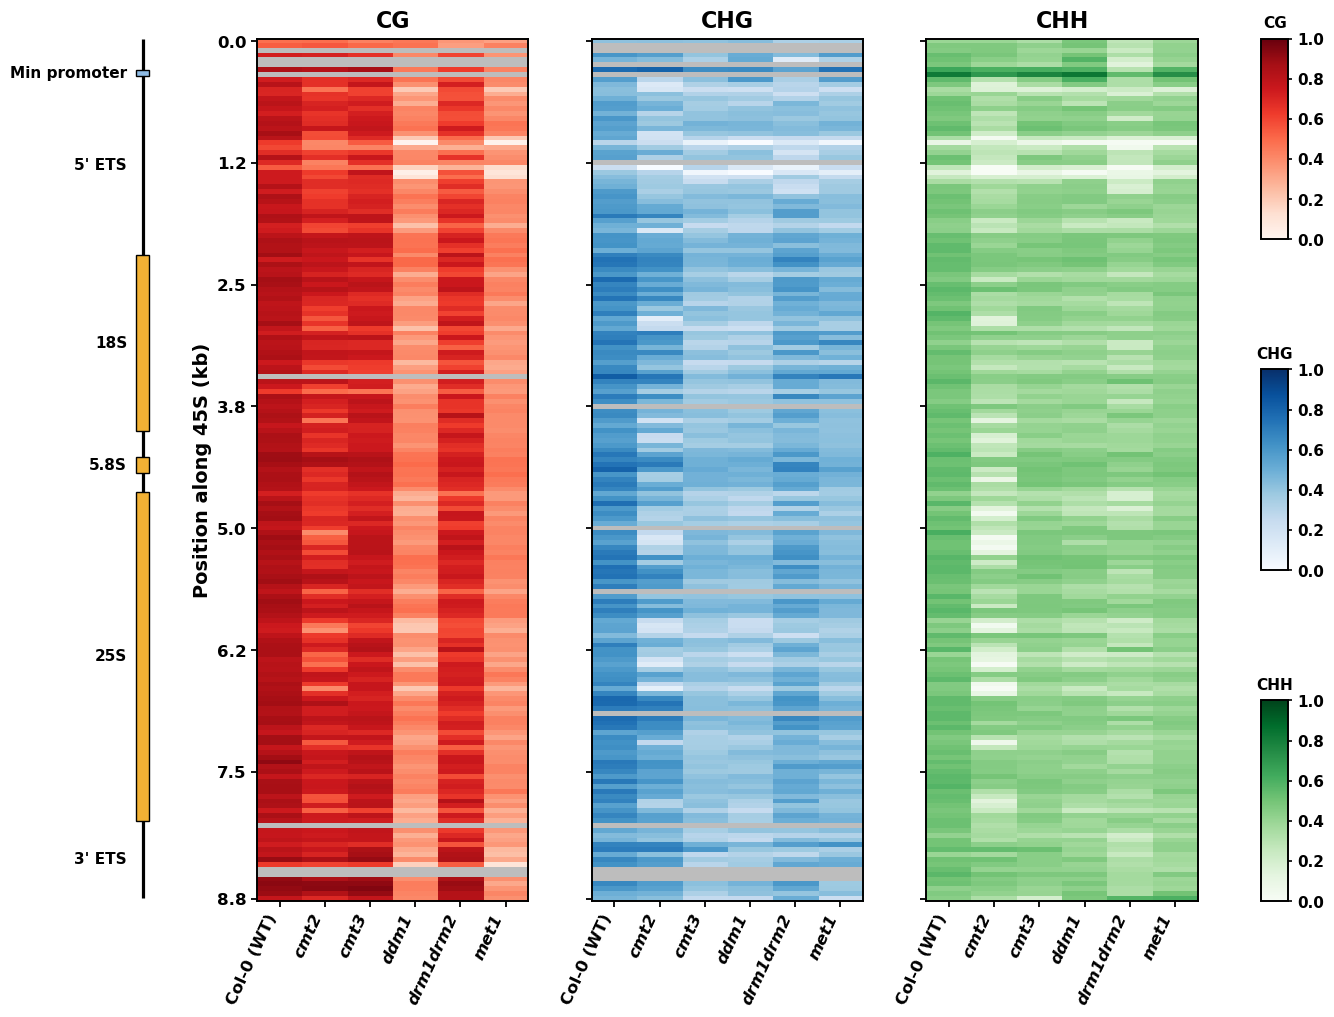

[ok] Saved updated publication binned heatmap:
     /home/silieslab/rDNA_repro/out/figures/Fig3_style_heatmaps_methylpy_BIN50_PUBLICATION_v2.png
     /home/silieslab/rDNA_repro/out/figures/Fig3_style_heatmaps_methylpy_BIN50_PUBLICATION_v2.svg


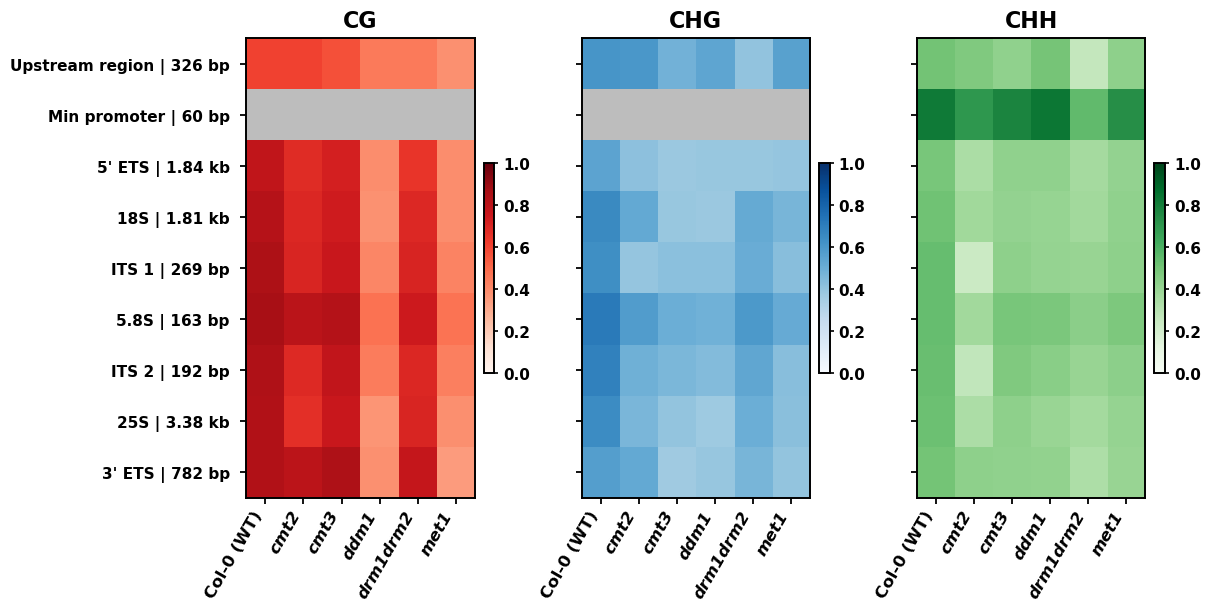

[ok] Saved updated publication region-wise methylpy heatmap:
     /home/silieslab/rDNA_repro/out/figures/methylpy_region_raw_fraction_heatmaps_rgb_PUBLICATION_v2.png
     /home/silieslab/rDNA_repro/out/figures/methylpy_region_raw_fraction_heatmaps_rgb_PUBLICATION_v2.svg


In [40]:
# =============================================================================
# Publication-ready figure versions (updated)
# -----------------------------------------------------------------------------
# Changes:
#   - Bold, readable, journal-style labels everywhere
#   - Consistent font sizes
#   - Mutant names italicized in both figures
#   - Col-0 (WT) kept non-italic
#   - Figure 1: horizontal annotation labels
#   - Figure 1: adds Upstream region, ITS 1, ITS 2
#   - Figure 2: removes square brackets from region labels
#   - Figure 2: adds Upstream region, ITS 1, ITS 2
#   - Figure 2: keeps region size in label
#   - Figure 2: no "Methylation fraction" colorbar label
#
# Saves:
#   out/figures/Fig3_style_heatmaps_methylpy_BIN50_PUBLICATION_v2.png
#   out/figures/Fig3_style_heatmaps_methylpy_BIN50_PUBLICATION_v2.svg
#   out/figures/methylpy_region_raw_fraction_heatmaps_rgb_PUBLICATION_v2.png
#   out/figures/methylpy_region_raw_fraction_heatmaps_rgb_PUBLICATION_v2.svg
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
ROOT = globals().get("PROJECT", Path.home() / "rDNA_repro")
WORK = globals().get("WORK", ROOT / "work")
REF  = globals().get("REF",  ROOT / "ref")
OUT  = globals().get("OUT",  ROOT / "out")

BIN_BP = int(globals().get("BIN_BP", 50))
FORCE = globals().get("FORCE", False)

MP_AGG_DIR = WORK / "methylpy_rDNA" / "aggregate"
FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ANN_PATH = REF / "45S_annotation.csv"
assert ANN_PATH.exists(), f"Missing annotation CSV: {ANN_PATH}"

cg_path   = MP_AGG_DIR / f"methylpy_binned_pivot_CG_BIN{BIN_BP}.csv"
chg_path  = MP_AGG_DIR / f"methylpy_binned_pivot_CHG_BIN{BIN_BP}.csv"
chh_path  = MP_AGG_DIR / f"methylpy_binned_pivot_CHH_BIN{BIN_BP}.csv"
long_path = MP_AGG_DIR / f"methylpy_binned_long_BIN{BIN_BP}.csv"

for p in [cg_path, chg_path, chh_path, long_path]:
    assert p.exists(), f"Missing {p}. Run the methylpy aggregation cell first."

# ---------------------------------------------------------------------
# Output paths
# ---------------------------------------------------------------------
fig1_png = FIG_DIR / f"Fig3_style_heatmaps_methylpy_BIN{BIN_BP}_PUBLICATION_v2.png"
fig1_svg = FIG_DIR / f"Fig3_style_heatmaps_methylpy_BIN{BIN_BP}_PUBLICATION_v2.svg"

fig2_png = FIG_DIR / "methylpy_region_raw_fraction_heatmaps_rgb_PUBLICATION_v2.png"
fig2_svg = FIG_DIR / "methylpy_region_raw_fraction_heatmaps_rgb_PUBLICATION_v2.svg"

# ---------------------------------------------------------------------
# Shared publication style
# ---------------------------------------------------------------------
PUB = {
    "title": 16,
    "axis": 14,
    "tick": 12,
    "small_tick": 11,
    "annotation": 11,
    "region": 11,
    "cbar": 11,
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "svg.fonttype": "none",
})

sample_order = ["WT_rep2", "cmt2", "cmt3", "ddm1", "drm1_2", "met1"]

display = {
    "WT_rep2": "Col-0 (WT)",
    "cmt2": "cmt2",
    "cmt3": "cmt3",
    "ddm1": "ddm1",
    "drm1_2": "drm1drm2",
    "met1": "met1",
}

contexts = ["CG", "CHG", "CHH"]

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def italicize_mutant_xticklabels(ax):
    """
    Italicize mutant names but keep Col-0 (WT) non-italic.
    """
    for lab in ax.get_xticklabels():
        txt = lab.get_text().strip().lower()

        if txt.startswith("col-0"):
            lab.set_fontstyle("normal")
        else:
            lab.set_fontstyle("italic")

        lab.set_fontweight("bold")


def norm_feature(x):
    x = str(x).strip().lower()
    x = x.replace("′", "'")
    x = x.replace("_", "")
    x = x.replace(" ", "")
    x = x.replace("-", "")
    x = x.replace(".", "")
    return x


def canonical_feature_name(raw_name):
    n = norm_feature(raw_name)

    if "promoter" in n:
        return "min_promoter"
    if n in {"5pets", "5ets", "5petr"} or ("5" in n and "ets" in n and "3" not in n):
        return "5p_ets"
    if n == "18s" or "18s" in n:
        return "18s"
    if n in {"58s", "5 8s"} or "58s" in n:
        return "5.8s"
    if n == "25s" or "25s" in n:
        return "25s"
    if n in {"3pets", "3ets"} or ("3" in n and "ets" in n):
        return "3p_ets"
    if n == "its1":
        return "its1"
    if n == "its2":
        return "its2"

    return str(raw_name).strip()


def label_for_fig1(name):
    mapping = {
        "upstream_region": "",
        "min_promoter": "Min promoter",
        "5p_ets": "5' ETS",
        "18s": "18S",
        "its1": "",
        "5.8s": "5.8S",
        "its2": "",
        "25s": "25S",
        "3p_ets": "3' ETS",
    }
    return mapping.get(name, str(name))


def label_for_fig2(name):
    mapping = {
        "upstream_region": "Upstream region",
        "min_promoter": "Min promoter",
        "5p_ets": "5' ETS",
        "18s": "18S",
        "its1": "ITS 1",
        "5.8s": "5.8S",
        "its2": "ITS 2",
        "25s": "25S",
        "3p_ets": "3' ETS",
    }
    return mapping.get(name, str(name))


def cmap_with_grey(name):
    cm = plt.get_cmap(name).copy()
    cm.set_bad(color="#bdbdbd")
    return cm


cm_cg  = cmap_with_grey("Reds")
cm_chg = cmap_with_grey("Blues")
cm_chh = cmap_with_grey("Greens")


def region_size_text(size_bp):
    if size_bp >= 1000:
        return f"{size_bp / 1000:.2f} kb"
    return f"{int(size_bp)} bp"


# ---------------------------------------------------------------------
# Load annotation
# ---------------------------------------------------------------------
ann = pd.read_csv(ANN_PATH)
ann.columns = [c.strip().lower() for c in ann.columns]

if "kind" not in ann.columns and "type" in ann.columns:
    ann = ann.rename(columns={"type": "kind"})

for col in ["feature", "start_bp", "end_bp"]:
    assert col in ann.columns, f"Annotation CSV missing '{col}'. Found: {list(ann.columns)}"

if "kind" not in ann.columns:
    ann["kind"] = "box"

ann["feature"]  = ann["feature"].astype(str).str.strip()
ann["kind"]     = ann["kind"].astype(str).str.strip().str.lower()
ann["start_bp"] = ann["start_bp"].astype(int)
ann["end_bp"]   = ann["end_bp"].astype(int)

ann["feature_key"] = ann["feature"].map(canonical_feature_name)

# ---------------------------------------------------------------------
# Build ordered region table with inserted gap regions
# ---------------------------------------------------------------------
base = {}

for _, r in ann.sort_values(["start_bp", "end_bp"]).iterrows():
    k = r["feature_key"]

    if k not in base:
        base[k] = {
            "feature_key": k,
            "start_bp": int(r["start_bp"]),
            "end_bp": int(r["end_bp"]),
            "kind": str(r["kind"]),
        }

required = ["min_promoter", "5p_ets", "18s", "5.8s", "25s", "3p_ets"]
missing_required = [k for k in required if k not in base]
assert not missing_required, f"Missing required annotation features: {missing_required}"

ann_pub_rows = []

# upstream region
if base["min_promoter"]["start_bp"] > 0:
    ann_pub_rows.append({
        "feature_key": "upstream_region",
        "start_bp": 0,
        "end_bp": base["min_promoter"]["start_bp"],
        "kind": "line",
    })

# promoter
ann_pub_rows.append(base["min_promoter"])

# 5' ETS
ann_pub_rows.append(base["5p_ets"])

# 18S
ann_pub_rows.append(base["18s"])

# ITS1
its1_start = base["18s"]["end_bp"]
its1_end   = base["5.8s"]["start_bp"]

if its1_end > its1_start:
    ann_pub_rows.append({
        "feature_key": "its1",
        "start_bp": its1_start,
        "end_bp": its1_end,
        "kind": "line",
    })

# 5.8S
ann_pub_rows.append(base["5.8s"])

# ITS2
its2_start = base["5.8s"]["end_bp"]
its2_end   = base["25s"]["start_bp"]

if its2_end > its2_start:
    ann_pub_rows.append({
        "feature_key": "its2",
        "start_bp": its2_start,
        "end_bp": its2_end,
        "kind": "line",
    })

# 25S
ann_pub_rows.append(base["25s"])

# 3' ETS
ann_pub_rows.append(base["3p_ets"])

ann_pub = pd.DataFrame(ann_pub_rows).copy()
ann_pub["feature_fig1"] = ann_pub["feature_key"].map(label_for_fig1)
ann_pub["feature_fig2"] = ann_pub["feature_key"].map(label_for_fig2)
ann_pub["size_bp"] = ann_pub["end_bp"] - ann_pub["start_bp"]

# =============================================================================
# Figure 1:
# 50 bp binned heatmap with updated annotation labels
# =============================================================================

CG  = pd.read_csv(cg_path,  index_col=0)
CHG = pd.read_csv(chg_path, index_col=0)
CHH = pd.read_csv(chh_path, index_col=0)

order = [
    s for s in sample_order
    if s in CG.index and s in CHG.index and s in CHH.index
]

assert order, "None of the expected samples were found in all three methylpy pivot tables."


def prep_binned(mat):
    mat = mat.copy()
    mat.columns = mat.columns.astype(int)
    mat = mat.reindex(order)

    mat_t = mat.T.sort_index()

    A = mat_t.to_numpy(dtype=float)
    ybins = mat_t.index.astype(int).to_numpy()
    xlab = [display.get(s, s) for s in order]

    return A, ybins, xlab


A_cg, ybins, xlab = prep_binned(CG)
A_chg, _, _ = prep_binned(CHG)
A_chh, _, _ = prep_binned(CHH)

fig = plt.figure(figsize=(15.0, 11.2))

gs = fig.add_gridspec(
    nrows=1,
    ncols=5,
    width_ratios=[0.25, 1.0, 1.0, 1.0, 0.10],
    wspace=0.35,
)

ax_ann = fig.add_subplot(gs[0, 0])
ax_cg  = fig.add_subplot(gs[0, 1])
ax_chg = fig.add_subplot(gs[0, 2], sharey=ax_cg)
ax_chh = fig.add_subplot(gs[0, 3], sharey=ax_cg)

gs_cb = gs[0, 4].subgridspec(nrows=3, ncols=1, hspace=0.65)
cax_cg  = fig.add_subplot(gs_cb[0, 0])
cax_chg = fig.add_subplot(gs_cb[1, 0])
cax_chh = fig.add_subplot(gs_cb[2, 0])


def draw_binned_panel(ax, A, title, cmap, cax):
    im = ax.imshow(
        np.ma.masked_invalid(A),
        aspect="auto",
        origin="upper",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
        cmap=cmap,
    )

    ax.set_title(
        title,
        fontsize=PUB["title"],
        fontweight="bold",
        pad=8,
    )

    ax.set_xticks(np.arange(len(xlab)))
    ax.set_xticklabels(
        xlab,
        rotation=65,
        ha="right",
        fontsize=PUB["tick"],
        fontweight="bold",
    )

    italicize_mutant_xticklabels(ax)

    n = len(ybins)

    if n > 1:
        yt = np.linspace(0, n - 1, 8).astype(int)
        ax.set_yticks(yt)
        ax.set_yticklabels(
            [f"{ybins[i] / 1000:.1f}" for i in yt],
            fontsize=PUB["tick"],
            fontweight="bold",
        )

    ax.tick_params(axis="both", width=1.3, length=4)

    cb = fig.colorbar(im, cax=cax)
    cb.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cb.ax.tick_params(labelsize=PUB["cbar"], width=1.2, length=3)

    for t in cb.ax.get_yticklabels():
        t.set_fontweight("bold")

    cax.set_title(
        title,
        fontsize=PUB["cbar"],
        fontweight="bold",
        pad=8,
    )

    return im


draw_binned_panel(ax_cg,  A_cg,  "CG",  cm_cg,  cax_cg)
draw_binned_panel(ax_chg, A_chg, "CHG", cm_chg, cax_chg)
draw_binned_panel(ax_chh, A_chh, "CHH", cm_chh, cax_chh)

plt.setp(ax_chg.get_yticklabels(), visible=False)
plt.setp(ax_chh.get_yticklabels(), visible=False)

ax_cg.set_ylabel(
    "Position along 45S (kb)",
    fontsize=PUB["axis"],
    fontweight="bold",
)

# Annotation track
nrows = len(ybins)


def bp_to_row(bp):
    return bp / BIN_BP


ax_ann.set_xlim(0, 1)
ax_ann.set_ylim(nrows, 0)
ax_ann.axis("off")

track_x0, track_w = 0.15, 0.2
line_x = track_x0 + track_w / 2

feature_colors = {
    "min_promoter": "#8fbce6",
    "5p_ets": "#8fbce6",
    "18s": "#f2b134",
    "5.8s": "#f2b134",
    "25s": "#f2b134",
    "3p_ets": "#f2b134",
}

# Draw track segments
for _, r in ann_pub.iterrows():
    y0 = bp_to_row(r["start_bp"])
    y1 = bp_to_row(r["end_bp"])
    kind = r["kind"]
    feat_key = r["feature_key"]

    if kind == "line":
        ax_ann.plot(
            [line_x, line_x],
            [y0, y1],
            lw=2.3,
            color="black",
            solid_capstyle="butt",
        )
    else:
        col = feature_colors.get(feat_key, "#f2b134")

        ax_ann.add_patch(
            Rectangle(
                (track_x0, y0),
                track_w,
                y1 - y0,
                facecolor=col,
                edgecolor="black",
                lw=1.0,
            )
        )

# Compute text positions with simple non-overlap spacing
mids = [
    bp_to_row(0.5 * (r["start_bp"] + r["end_bp"]))
    for _, r in ann_pub.iterrows()
]

adj = mids.copy()
min_gap = 3.2  # in heatmap rows

for i in range(1, len(adj)):
    if adj[i] - adj[i - 1] < min_gap:
        adj[i] = adj[i - 1] + min_gap

upper_lim = nrows - 1.0

if adj[-1] > upper_lim:
    adj[-1] = upper_lim

    for i in range(len(adj) - 2, -1, -1):
        adj[i] = min(adj[i], adj[i + 1] - min_gap)
        adj[i] = max(adj[i], 0.8)

# Draw labels
for i, (_, r) in enumerate(ann_pub.iterrows()):
    ax_ann.text(
        0.02,
        adj[i],
        r["feature_fig1"],
        va="center",
        ha="right",
        fontsize=PUB["annotation"],
        fontweight="bold",
        rotation=0,
        linespacing=0.95,
    )

plt.savefig(fig1_png, dpi=600, bbox_inches="tight")
plt.savefig(fig1_svg, bbox_inches="tight")
plt.show()

print(f"[ok] Saved updated publication binned heatmap:")
print(f"     {fig1_png}")
print(f"     {fig1_svg}")

# =============================================================================
# Figure 2:
# Region-wise heatmap with no square brackets and inserted regions
# =============================================================================

long = pd.read_csv(long_path)

req = {"sample", "bin_start", "context", "meth", "unmeth"}
assert req.issubset(long.columns), f"Missing columns in long table: {req - set(long.columns)}"


def region_aggregate(region_name, start_bp, end_bp):
    sub = long[
        (long["bin_start"] >= start_bp) &
        (long["bin_start"] < end_bp)
    ].copy()

    if sub.empty:
        return None

    out = (
        sub.groupby(["context", "sample"], as_index=False)
           .agg(meth=("meth", "sum"), unmeth=("unmeth", "sum"))
    )

    out["region"] = region_name
    out["fraction"] = out["meth"] / (out["meth"] + out["unmeth"])

    return out


parts = []

for _, r in ann_pub.iterrows():
    tmp = region_aggregate(
        r["feature_key"],
        int(r["start_bp"]),
        int(r["end_bp"]),
    )

    if tmp is not None:
        parts.append(tmp)

assert parts, "No region-level methylation rows were produced."

region_sum = pd.concat(parts, ignore_index=True)

abs_mat = region_sum.pivot_table(
    index=["region", "context"],
    columns="sample",
    values="fraction",
)

col_order = (
    [c for c in sample_order if c in abs_mat.columns] +
    [c for c in abs_mat.columns if c not in sample_order]
)

region_order = ann_pub["feature_key"].tolist()
region_order = [
    r for r in region_order
    if r in abs_mat.index.get_level_values("region")
]

region_meta = {}

for _, r in ann_pub.iterrows():
    feat = str(r["feature_key"])

    if feat not in region_meta:
        region_meta[feat] = {
            "start_bp": int(r["start_bp"]),
            "end_bp": int(r["end_bp"]),
        }


def make_panel(context):
    M = abs_mat.xs(context, level="context")
    M = M.reindex(region_order)
    M = M.reindex(columns=col_order)
    return M


M_CG  = make_panel("CG")
M_CHG = make_panel("CHG")
M_CHH = make_panel("CHH")


def region_label(region_key):
    start = int(region_meta[region_key]["start_bp"])
    end = int(region_meta[region_key]["end_bp"])
    size_bp = max(0, end - start)

    return f"{label_for_fig2(region_key)} | {region_size_text(size_bp)}"


ylabels = [region_label(r) for r in region_order]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 6),
    constrained_layout=True,
)

panel_info = [
    ("CG",  M_CG,  cm_cg),
    ("CHG", M_CHG, cm_chg),
    ("CHH", M_CHH, cm_chh),
]

for ax, (title, M, cmap) in zip(axes, panel_info):
    A = M.to_numpy(dtype=float)

    im = ax.imshow(
        np.ma.masked_invalid(A),
        aspect="auto",
        origin="upper",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
        cmap=cmap,
    )

    ax.set_title(
        title,
        fontsize=PUB["title"],
        fontweight="bold",
        pad=8,
    )

    ax.set_xticks(np.arange(len(M.columns)))
    ax.set_xticklabels(
        [display.get(x, x) for x in M.columns],
        rotation=60,
        ha="right",
        fontsize=PUB["tick"],
        fontweight="bold",
    )

    italicize_mutant_xticklabels(ax)

    ax.set_yticks(np.arange(len(M.index)))

    if ax is axes[0]:
        ax.set_yticklabels(
            ylabels,
            fontsize=PUB["region"],
            fontweight="bold",
            ha="right",
        )
        ax.tick_params(axis="y", pad=8)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)

    ax.tick_params(axis="both", width=1.3, length=4)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.ax.tick_params(labelsize=PUB["cbar"], width=1.2, length=3)

    for t in cbar.ax.get_yticklabels():
        t.set_fontweight("bold")

plt.savefig(fig2_png, dpi=600, bbox_inches="tight")
plt.savefig(fig2_svg, bbox_inches="tight")
plt.show()

print(f"[ok] Saved updated publication region-wise methylpy heatmap:")
print(f"     {fig2_png}")
print(f"     {fig2_svg}")